In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [2]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x2edff4dd5ab9f321, 0xd83e7cdb699396f7, 0x984b958cebaed568, 0x54db6d28e8736274, 0x2decfb5c305ed86d, 0x407e6290a6f4bd0b, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [3]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 20.0, r = 1.0), (m₀ = Uniform{Float64}(a=0.001, b=2.0), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=1.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#50"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}(OscillationConf

In [4]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [5]:
experiments = (

  juno= Newtrinos.juno.configure(physics),
);

[ Info: Loading juno data


In [6]:
p = Newtrinos.get_params(experiments)

(N = 20.0, juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [7]:
using Setfield
using CairoMakie

In [8]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3)) )
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 20.0, juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.12479708646125824, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [9]:
assets= experiments.juno.assets

(visible_to_neutrino_interp = 65-element extrapolate(interpolate((::Vector{Float64},), ::Vector{Float64}, Gridded(Linear())), Flat()) with element type Float64:
 1.8055709847970536
 1.8531830525211386
 1.8722278796107727
 1.89908504597914
 1.9456710691435752
 1.9755163652821492
 2.0361069966467116
 2.0820089901047134
 2.137091382254315
 2.1462717809459155
 2.2013541730955173
 2.2564365652451195
 2.3115189573947212
 ⋮
 6.8099143162788796
 6.9568006953444845
 7.131228270484891
 7.348497706186099
 7.535165812915305
 7.737134584130513
 7.939103355345719
 8.141072126560928
 8.343040897776135
 8.550517908206299
 8.717727169865665
 8.927526281141354, no_osc_interp = 65-element extrapolate(interpolate((::Vector{Float64},), ::Vector{Float64}, Gridded(Linear())), 0) with element type Float64:
  13.537376275037532
  95.62164937544527
 151.5927904728713
 228.70837353867216
 298.3535182304651
 360.39142969384324
 444.48645756071636
 507.7566030686267
 572.3712175722616
 622.9552928950469
 698.19529

In [10]:
expected_un = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))


376-element Vector{Float64}:
  66.01769446694799
  90.15980968246068
 123.05800655595053
 157.7870300997524
 196.0589543002465
 231.59173102461367
 260.778083503674
 287.85809207508237
 311.43088955740706
 331.8420597022671
 351.8216823037977
 366.60651503271083
 378.77815113917666
   ⋮
   5.0218842561256585
   4.925350887892226
   4.845106793150647
   4.779012105008405
   4.725029218826931
   4.681242714609578
   4.645891736274247
   4.617402999228017
   4.594413854982742
   4.57577980270192
   4.560566313088394
   4.548028637265404

In [11]:
expected_norm = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))


376-element Vector{Float64}:
  66.03152844014757
  90.14984252241484
 123.01289673962218
 157.73690086192346
 196.07885289003556
 231.7213592605916
 260.9575242082862
 287.96881325982383
 311.37551927996145
 331.6045201412426
 351.49113713775733
 366.3177553395436
 378.61931756641434
   ⋮
   5.022142110873469
   4.926006226079691
   4.846160179615887
   4.780462727725024
   4.726874903473883
   4.683480359248813
   4.648517918573326
   4.620414500108629
   4.597807936843843
   4.579554202153778
   4.564719002988928
   4.552557459449515

In [12]:
# standard model for comparison
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc, atm_flux, earth_layers);

experiments_SM = (

  juno= Newtrinos.juno.configure(physics_SM),
 

);

p_SM = Newtrinos.get_params(experiments_SM)



[ Info: Loading juno data


(juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [13]:
asimov_data= Newtrinos.generate_toy_data(experiments_SM.juno, p_SM)
observed = Float64.(asimov_data)

376-element Vector{Float64}:
  62.0
  85.0
 140.0
 172.0
 197.0
 235.0
 254.0
 257.0
 319.0
 347.0
 334.0
 337.0
 396.0
   ⋮
   5.0
   5.0
   5.0
   5.0
   8.0
   3.0
   3.0
   2.0
   4.0
   4.0
   3.0
   7.0

In [14]:
likelihood_SM=-Newtrinos.logdensityof(Newtrinos.juno.get_forward_model(physics_SM, assets)(p_SM), observed)

1516.106763509994

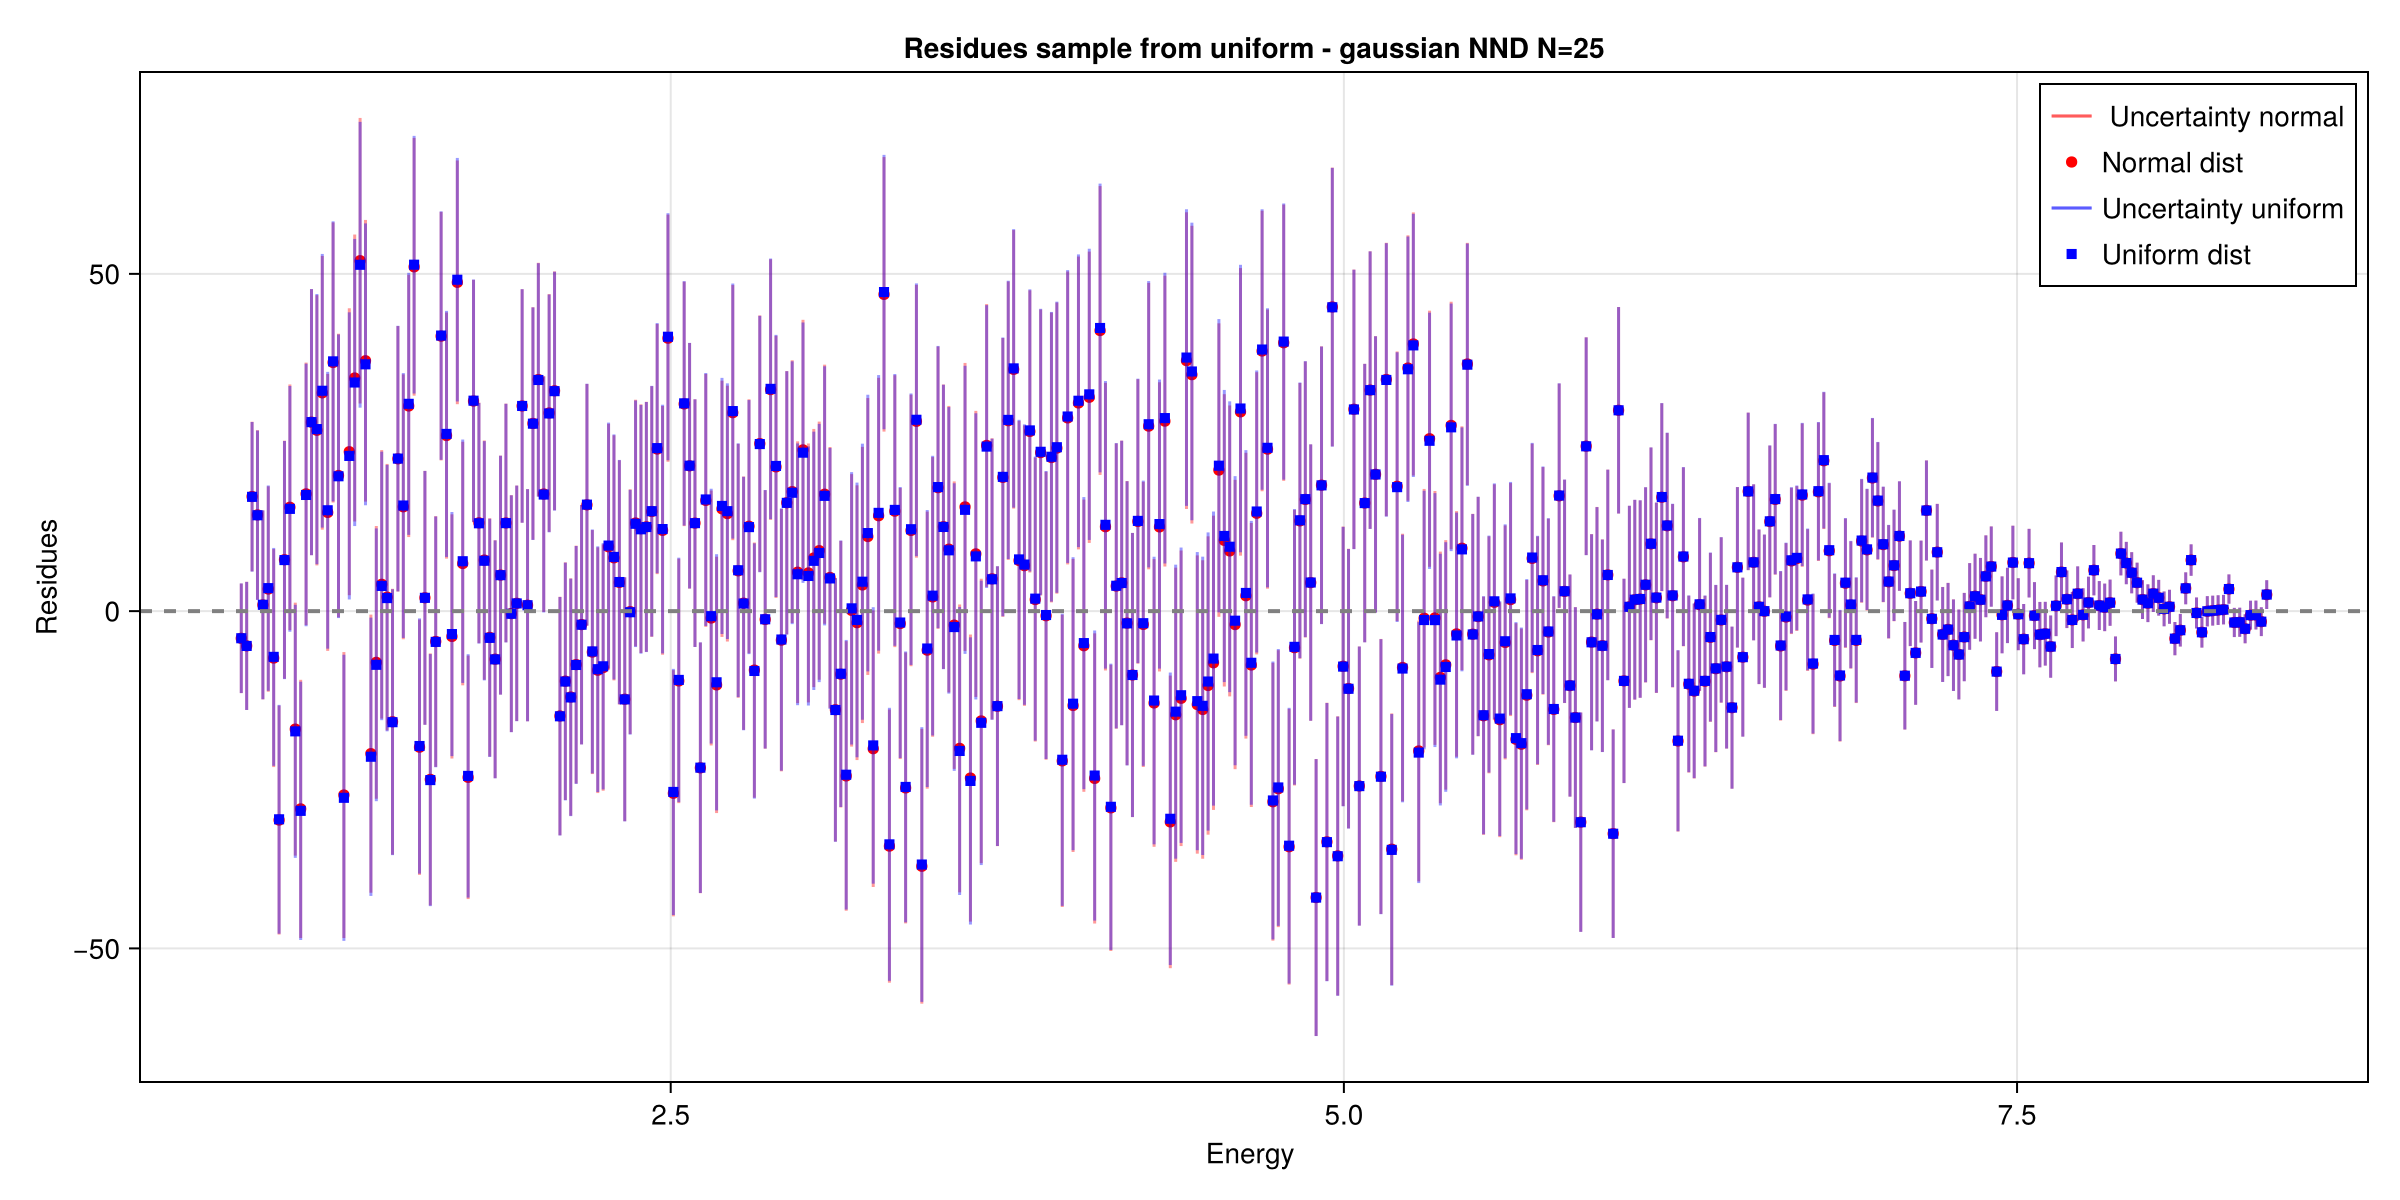

CairoMakie.Screen{IMAGE}


In [15]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NND N=25")


errorbars!(ax, assets.E_bins_visible,  observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.E_bins_visible,  observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.E_bins_visible,  observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")

scatter!(ax, assets.E_bins_visible, observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [16]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [17]:

using ProgressMeter
using MeasureBase

In [18]:
function random_sampling(physics, experiments, p, N)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/1000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
      new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm
      p_new_un = @set p.N = N
      p_new_norm = @set p.N = N

      assets= experiments.juno.assets
   

      expected_un = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm))

      #chi_squared_un = sum((observed.- expected_un).^2 ./ expected_un_var)
      #chi_squared_norm = sum((observed.- expected_norm).^2 ./ expected_norm_var)
      likelihood_norm=logdensityof(Newtrinos.juno.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.juno.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [132]:
trial=random_sampling(physics, experiments, p)

Progress: 100%|█████████████████████████████████████████| Time: 1:15:09


([-1515.5086173775178, -1515.5227121775179, -1515.5261883519072, -1515.487239631065, -1515.5343081330518, -1515.5069536029728, -1515.5135405152641, -1515.5560464112525, -1515.5669383315242, -1515.55831963085  …  -1515.5235370377725, -1515.6227429054989, -1515.5677216327438, -1515.5231119945374, -1515.5452009503217, -1515.5618399443638, -1515.5465364213758, -1515.5310266897284, -1515.5832278237276, -1515.5469903221929], [-1515.5330334984883, -1515.518177547263, -1515.532556813789, -1515.5863351657686, -1515.5007467823407, -1515.560304966271, -1515.5517609570827, -1515.543451271769, -1515.508584612327, -1515.5513530868548  …  -1515.5444990220917, -1515.5173984202459, -1515.4965274302572, -1515.5453813282422, -1515.5121378813462, -1515.544416641503, -1515.5162711834876, -1515.5648760084255, -1515.5612561417777, -1515.5058589054377])

In [133]:
trial=.-trial # to have the negative log likelihood

([1515.5086173775178, 1515.5227121775179, 1515.5261883519072, 1515.487239631065, 1515.5343081330518, 1515.5069536029728, 1515.5135405152641, 1515.5560464112525, 1515.5669383315242, 1515.55831963085  …  1515.5235370377725, 1515.6227429054989, 1515.5677216327438, 1515.5231119945374, 1515.5452009503217, 1515.5618399443638, 1515.5465364213758, 1515.5310266897284, 1515.5832278237276, 1515.5469903221929], [1515.5330334984883, 1515.518177547263, 1515.532556813789, 1515.5863351657686, 1515.5007467823407, 1515.560304966271, 1515.5517609570827, 1515.543451271769, 1515.508584612327, 1515.5513530868548  …  1515.5444990220917, 1515.5173984202459, 1515.4965274302572, 1515.5453813282422, 1515.5121378813462, 1515.544416641503, 1515.5162711834876, 1515.5648760084255, 1515.5612561417777, 1515.5058589054377])

In [134]:
mean_un=mean(trial[1])
mean_norm=mean(trial[2])

1515.5395613788216

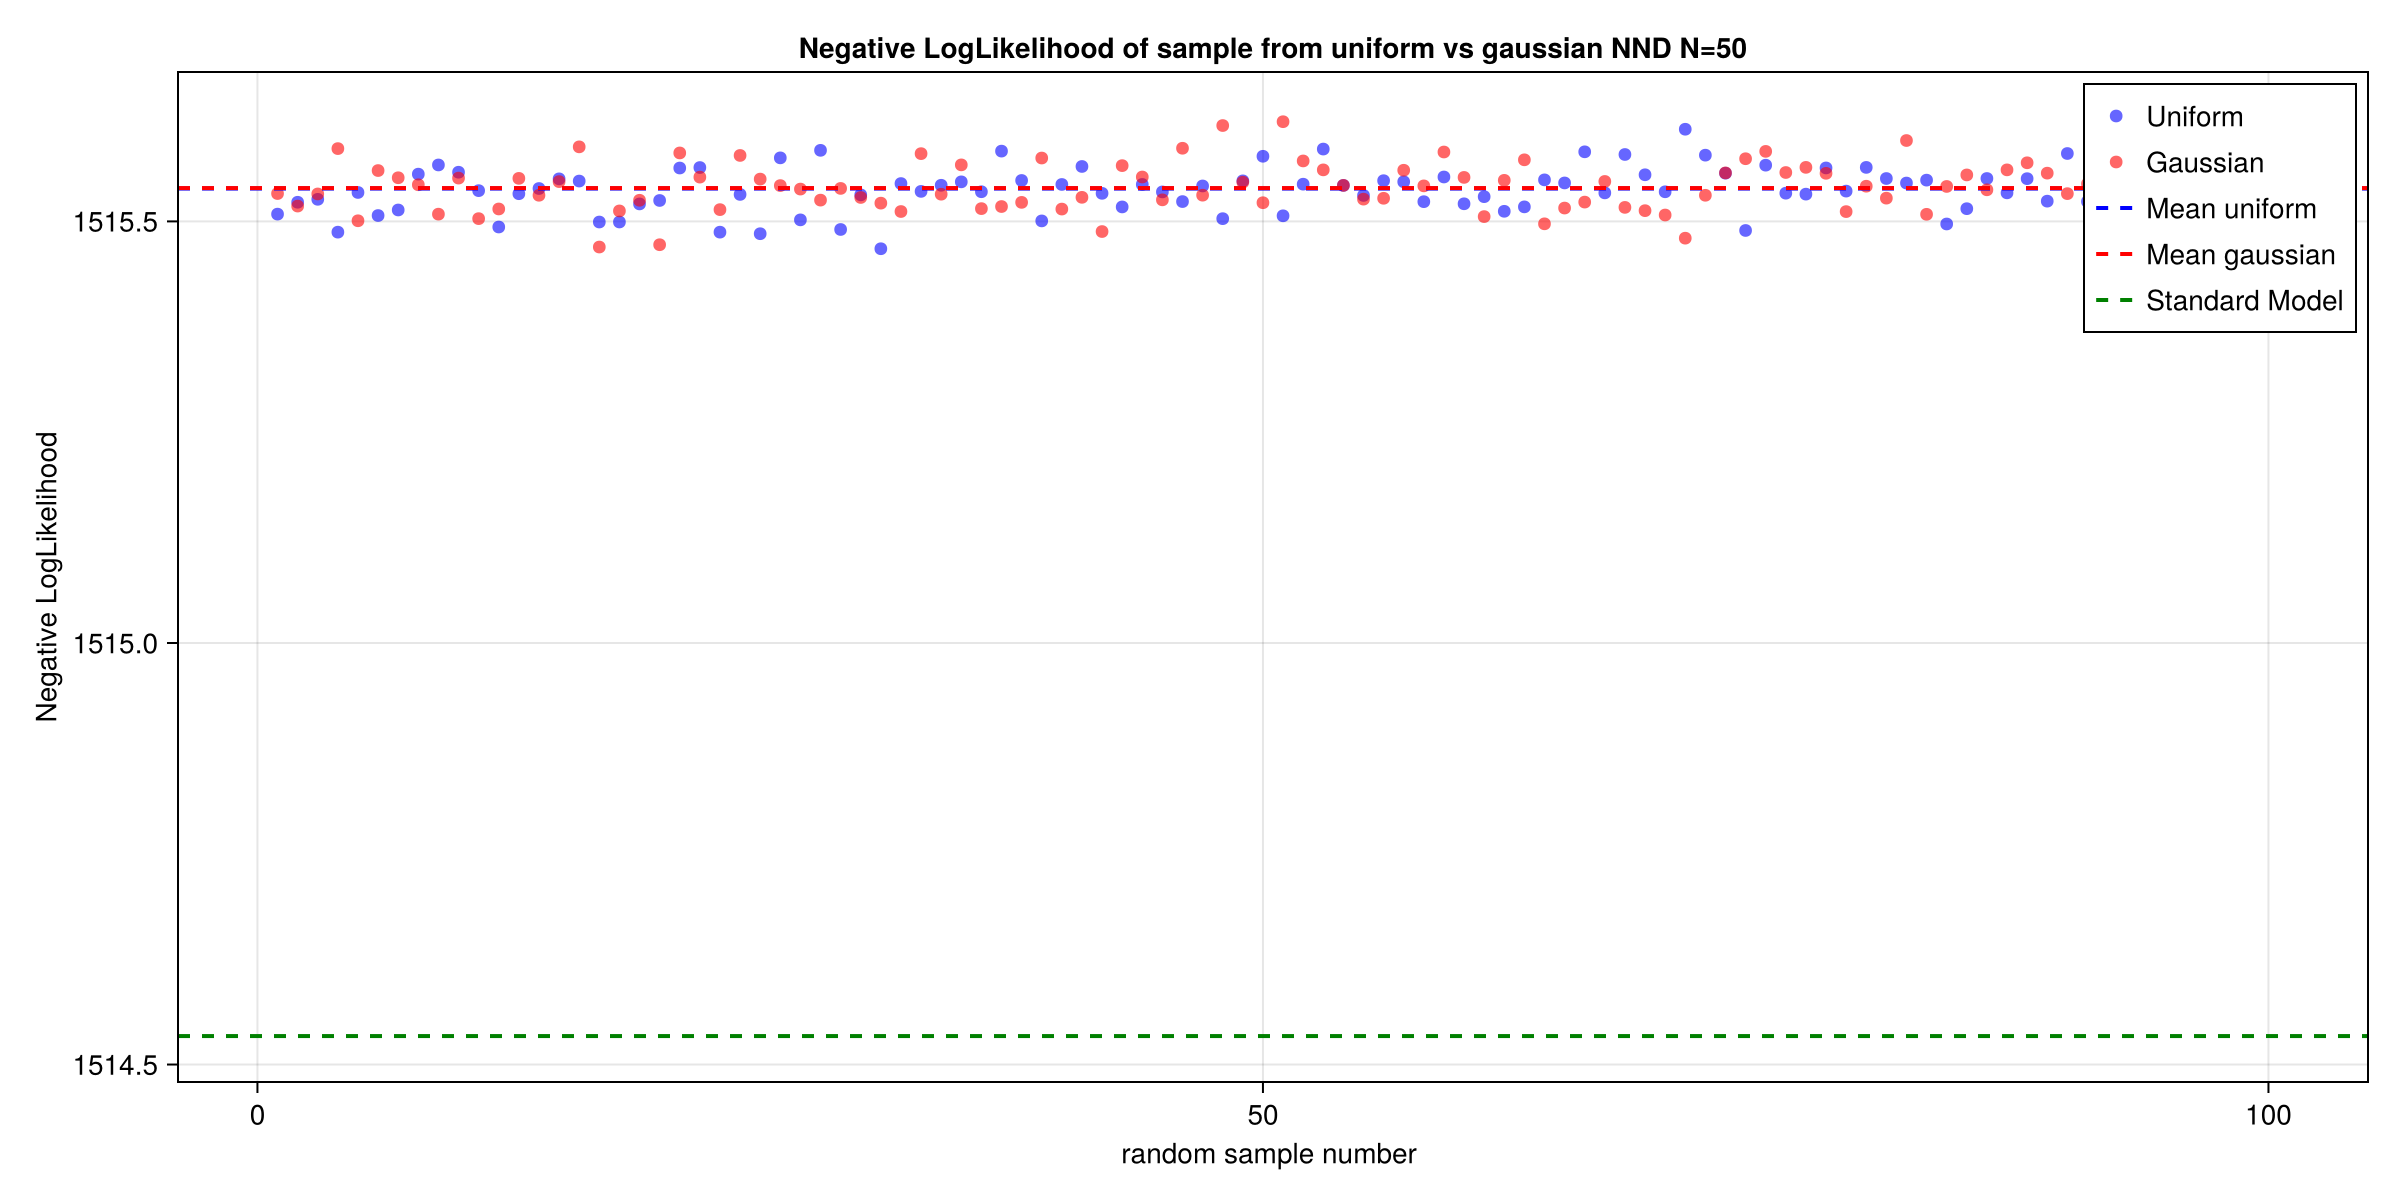

In [135]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "Negative LogLikelihood", 
    title = "Negative LogLikelihood of sample from uniform vs gaussian NND N=50")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.6), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.6), label = "Gaussian")


hlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
hlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
hlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/juno_samples_toy_NND_N50_m0=0.1.png", fig)

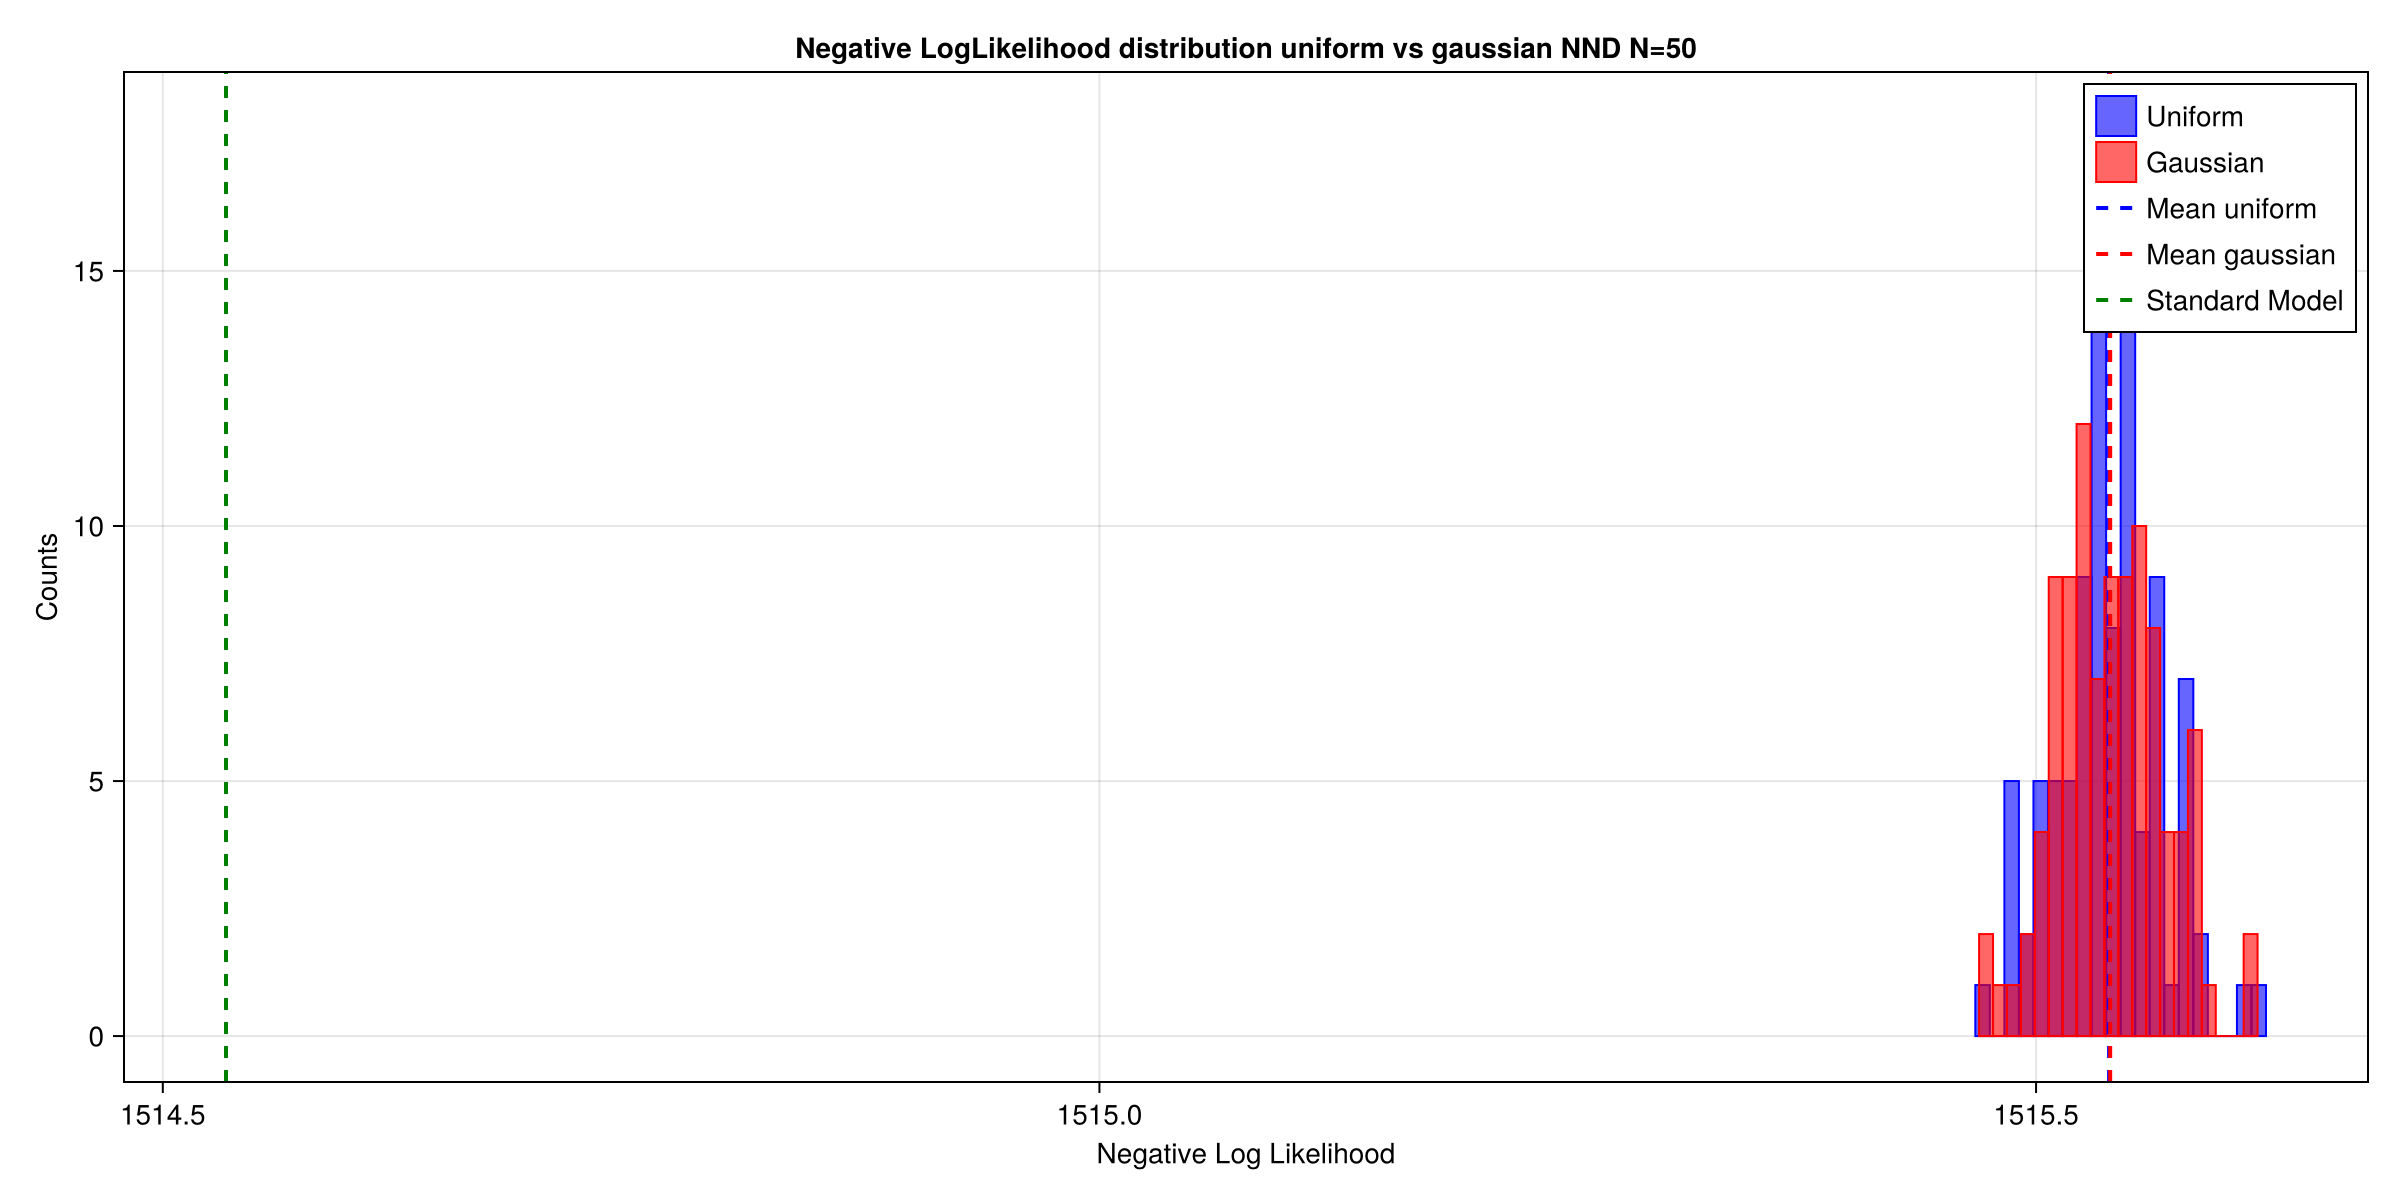

In [136]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " Negative Log Likelihood ",
    ylabel = "Counts", 
    title = "Negative LogLikelihood distribution uniform vs gaussian NND N=50")

hist!(ax, trial[1], bins = 20, color = (:blue, 0.6), strokewidth = 1, strokecolor = :blue, label = "Uniform")
hist!(ax, trial[2], bins = 20, color = (:red, 0.6), strokewidth = 1, strokecolor = :red, label = "Gaussian")



vlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
vlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
vlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/juno_nll_toy_NND_N50_m0=0.1.png", fig)

In [26]:
function lik_ratio(N)

    ratios_un = Float64[]
    ratios_norm = Float64[]

    likelihood_SM=-Newtrinos.logdensityof(Newtrinos.juno.get_forward_model(physics_SM, assets)(p_SM), observed)

   
    @showprogress for i in 1:N
       trial=random_sampling(physics, experiments, p, i)
       mean_un= mean(trial[1])
       mean_norm= mean(trial[2])
       ratio_un= 2*(likelihood_SM-mean_un)
       ratio_norm= 2*(likelihood_SM-mean_norm)

       push!(ratios_un, ratio_un)
       push!(ratios_norm, ratio_norm)
    end

     
    return ratios_un, ratios_norm
end

lik_ratio (generic function with 1 method)

In [36]:
likelihood_ratios= lik_ratio(20)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:03
Progress: 100%|█████████████████████████████████████████| Time: 0:00:05
Progress: 100%|█████████████████████████████████████████| Time: 0:00:15
Progress: 100%|█████████████████████████████████████████| Time: 0:00:19
Progress: 100%|█████████████████████████████████████████| Time: 0:00:34
Progress: 100%|█████████████████████████████████████████| Time: 0:00:48
Progress: 100%|█████████████████████████████████████████| Time: 0:01:08
Progress: 100%|█████████████████████████████████████████| Time: 0:01:32
Progress: 100%|█████████████████████████████████████████| Time: 0:01:58
Progress: 100%|█████████████████████████████████████████| Time: 0:02:26
Progress: 100%|█████████████████████████████████████████| Time: 0:04:35
Progress: 100%|█████████████████████████████████████████| Time: 0:04:01
Progress: 100%|█████████████████████████████████████████| Time: 

([6064.4270540399775, 14833.577789986859, 10162.628278341483, 7967.244321844545, 7029.044703036949, 6633.496166622317, 6420.398597114245, 6311.343009408614, 6243.004065076724, 6191.7269572227, 6157.237653312883, 6140.244457064766, 6124.599506233852, 6111.804169101032, 6103.778888818095, 6097.873514998764, 6091.274226652971, 6088.365475208162, 6084.698274171355, 6082.522725922718], [6064.4270540399775, 14833.577789986859, 10162.628278341483, 7967.244321844545, 7029.044703036949, 6633.496166622317, 6420.398597114245, 6311.343009408614, 6243.004065076724, 6191.7269572227, 6157.237653312883, 6140.244457064766, 6124.599506233852, 6111.804169101032, 6103.778888818095, 6097.873514998764, 6091.274226652971, 6088.365475208162, 6084.698274171355, 6082.522725922718])

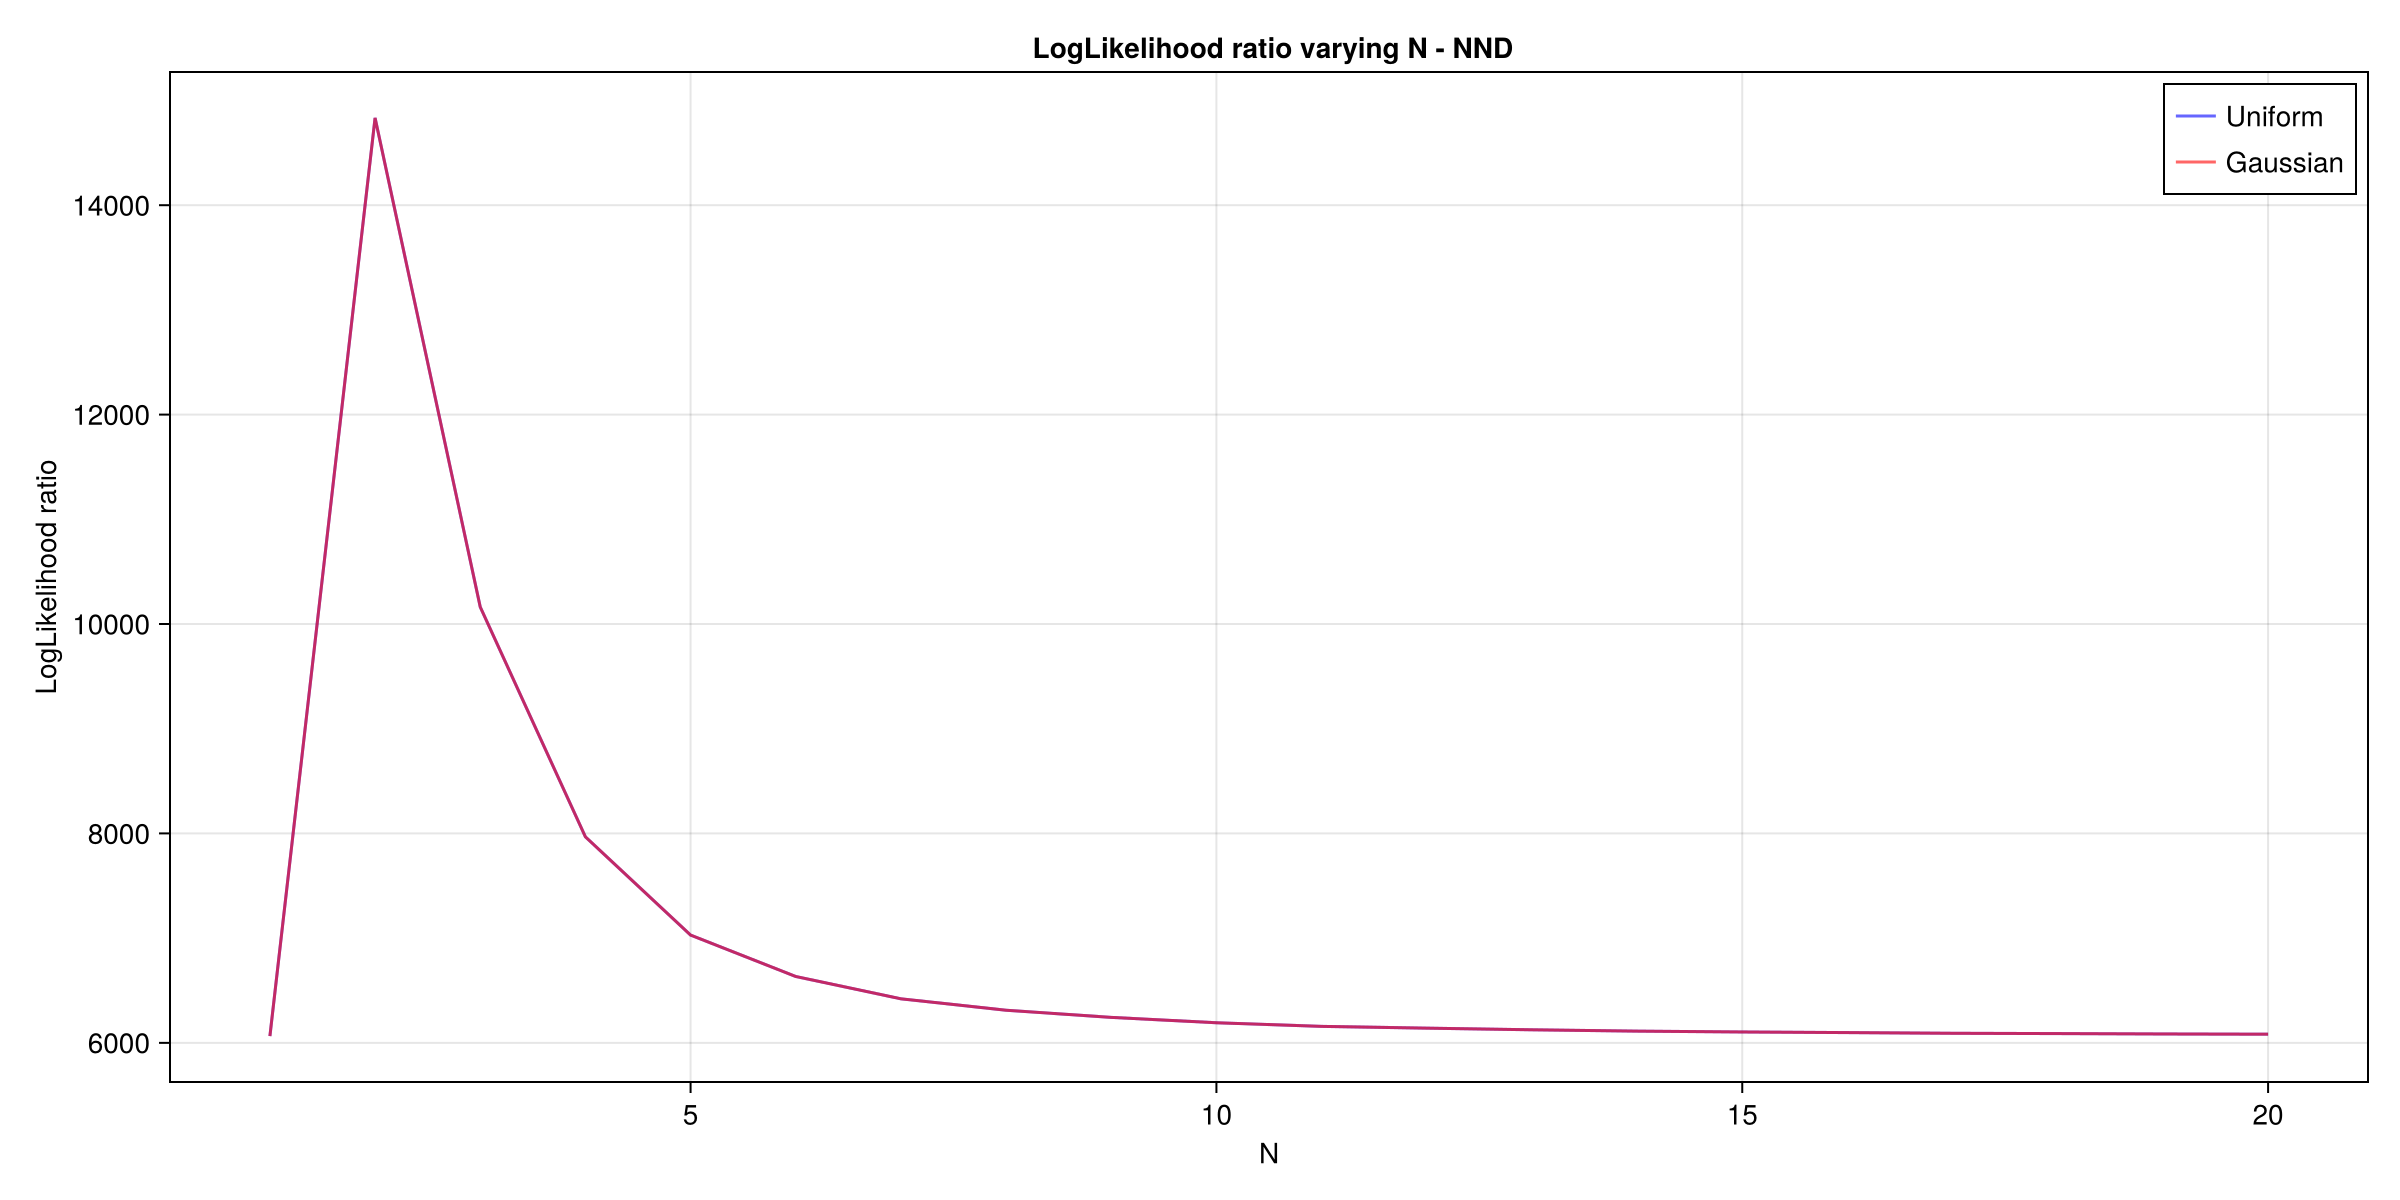

CairoMakie.Screen{IMAGE}


In [37]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " N ",
    ylabel = "LogLikelihood ratio", 
    title = " LogLikelihood ratio varying N - NND")

x=1:20    
lines!(x, likelihood_ratios[:][1], color = (:blue, 0.6),  label = "Uniform")
lines!(x, likelihood_ratios[:][2], color = (:red, 0.6),  label = "Gaussian")


# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

In [48]:
function lik_ratio(N)

    ratios_un = Float64[]
    ratios_norm = Float64[]

    pvalue_un = Float64[]
    pvalue_norm = Float64[]

    likelihood_SM=-Newtrinos.logdensityof(Newtrinos.juno.get_forward_model(physics_SM, assets)(p_SM), observed)

   
    @showprogress for i in 40:N
       trial=random_sampling(physics, experiments, p, i)
       mean_un= mean(trial[1])
       mean_norm= mean(trial[2])
       ratio_un= 2*(likelihood_SM-mean_un)
       ratio_norm= 2*(likelihood_SM-mean_norm)

       push!(ratios_un, ratio_un)
       push!(ratios_norm, ratio_norm)

       df = 3   # Difference in number of parameters

       p_value_un = 1 - cdf(Chisq(df), ratio_un)
       p_value_norm = 1 - cdf(Chisq(df), ratio_norm)

        push!(pvalue_un, p_value_un)
        push!(pvalue_norm, p_value_norm)

    end

     
    
    return ratios_un, ratios_norm, pvalue_un, pvalue_norm
end

lik_ratio (generic function with 1 method)

In [49]:
likelihood_ratios= lik_ratio(45)

Progress: 100%|█████████████████████████████████████████| Time: 0:48:21
Progress: 100%|█████████████████████████████████████████| Time: 1:11:23
Progress:  44%|██████████████████                       |  ETA: 0:28:01

LoadError: InterruptException:

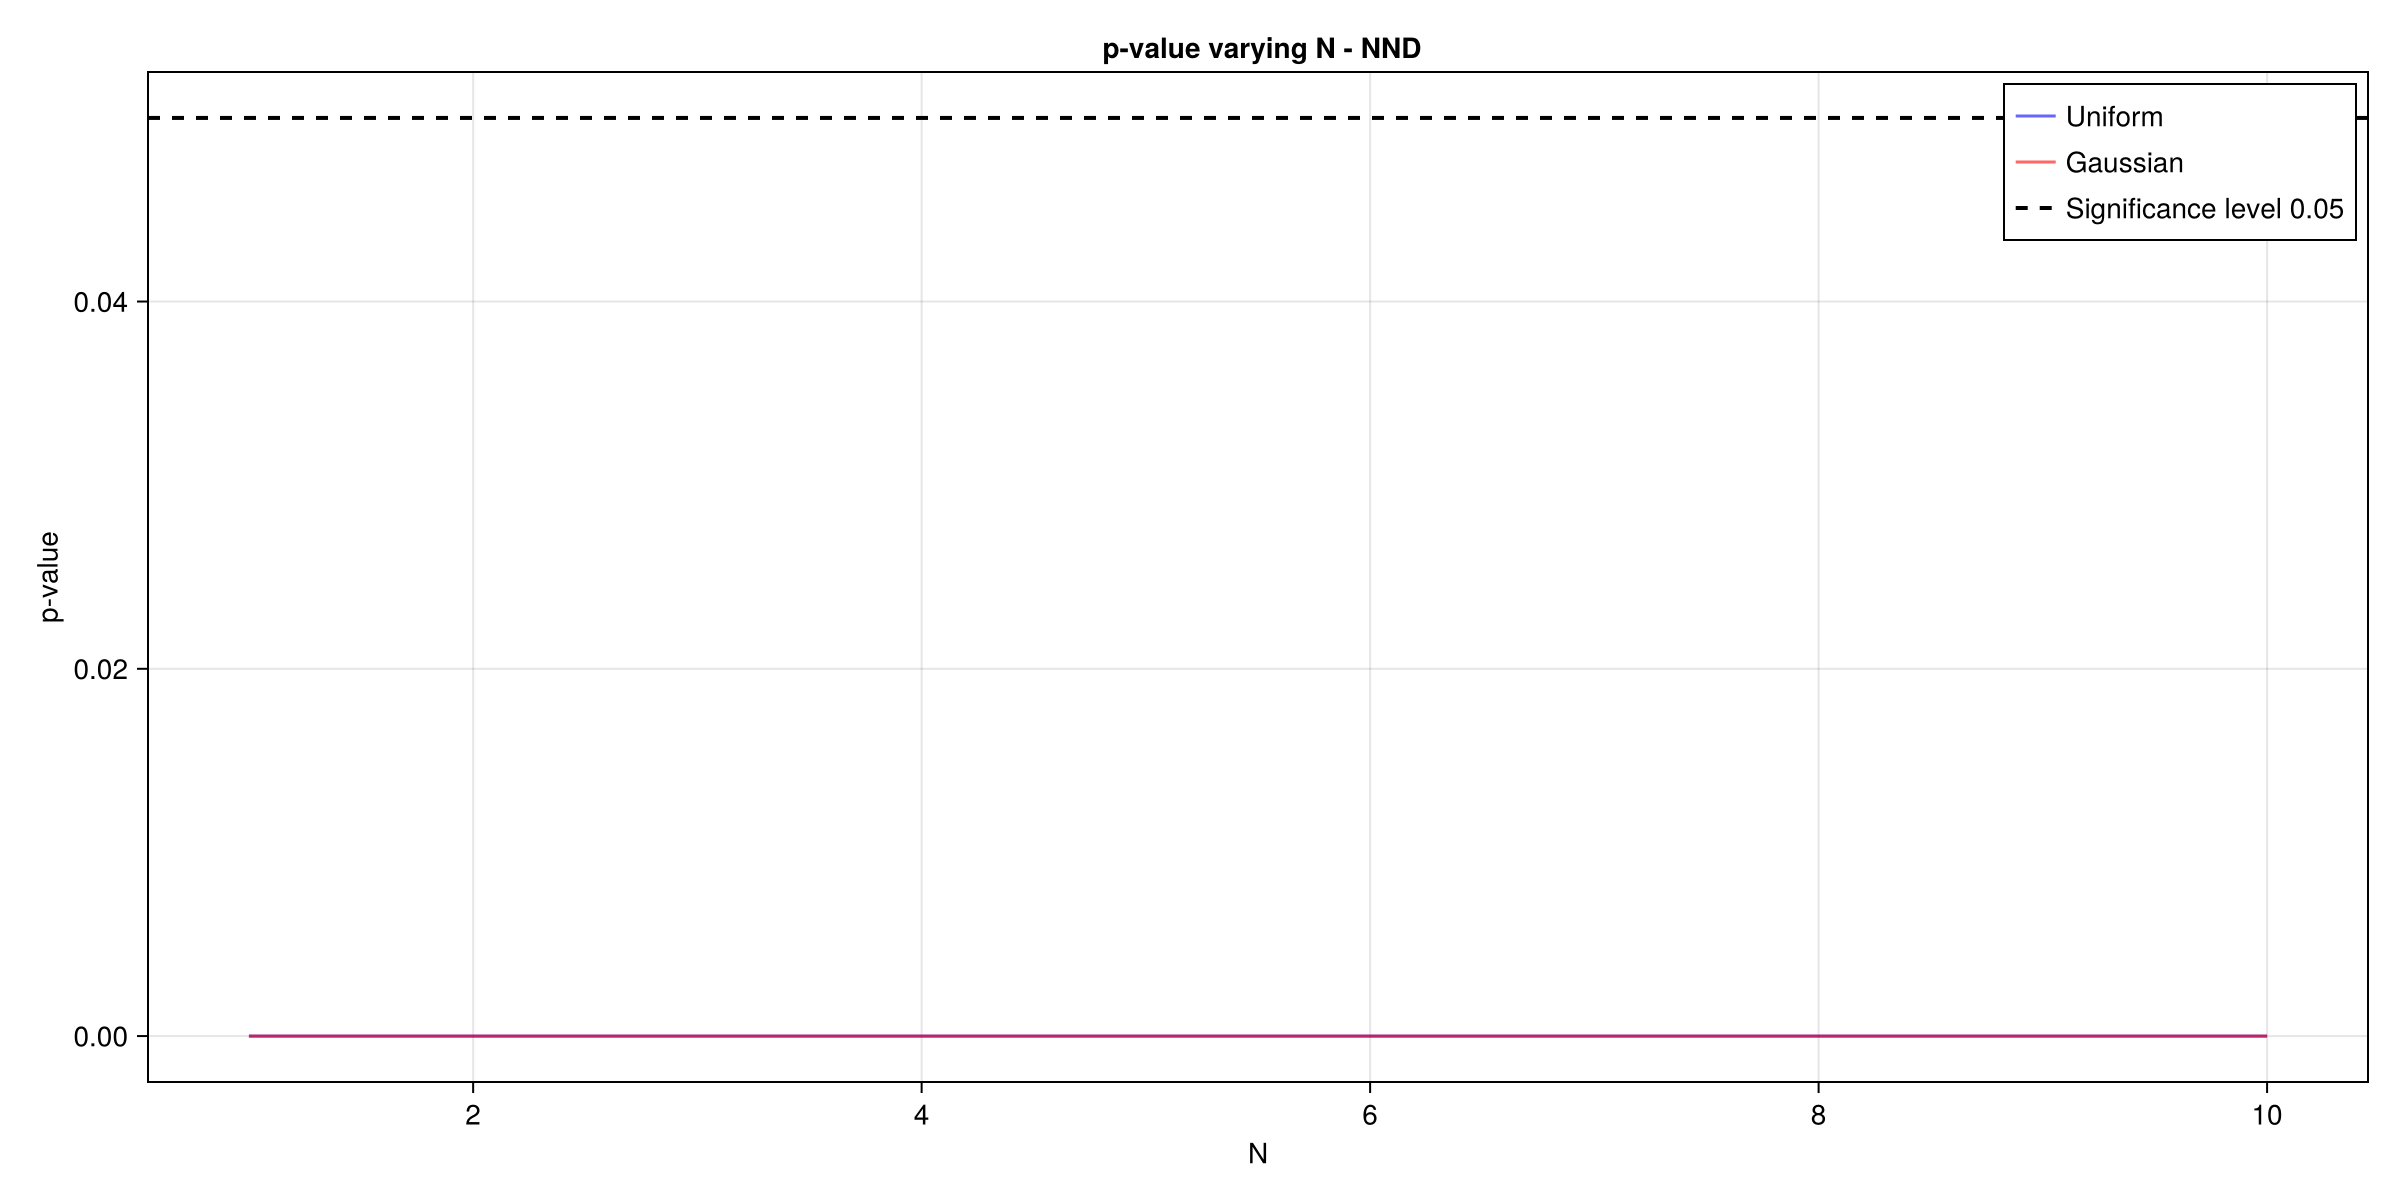

CairoMakie.Screen{IMAGE}


In [ ]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " N ",
    ylabel = "p-value", 
    title = " p-value varying N - NND")

x=1:10    
lines!(x, likelihood_ratios[:][3], color = (:blue, 0.6),  label = "Uniform")
lines!(x, likelihood_ratios[:][4], color = (:red, 0.6),  label = "Gaussian")

hlines!(0.05, color = :black, linestyle = :dash, linewidth = 2, label = "Significance level 0.05")
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)